<p style="font-family:Bookman Old Style;font-size:27px">Import libraries</p>

In [1]:
import cv2
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

<p style="font-family:Bookman Old Style;font-size:27px">Load and Preprocess the Image</p>

In [2]:
img = cv2.imread('../images-videos/lenna.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
img -= img.mean()

<p style="font-family:Bookman Old Style;font-size:27px">Add Gaussian Noise</p>

In [3]:
img = img + np.random.randn(*img.shape) * 60

<p style="font-family:Bookman Old Style;font-size:27px">Extract and Preprocess the Template</p>

In [4]:
template_img = np.copy(img[330:380, 200:380])
template_img -= template_img.mean()

<p style="font-family:Bookman Old Style;font-size:27px">Perform Cross-Correlation</p>

In [5]:
correlation = sc.signal.correlate2d(img, template_img, mode='same', boundary='symm')

<p style="font-family:Bookman Old Style;font-size:27px">Find the Best Match Location</p>

In [6]:
y, x = np.unravel_index(np.argmax(correlation), correlation.shape)

<p style="font-family:Bookman Old Style;font-size:27px">Visualize Results</p>

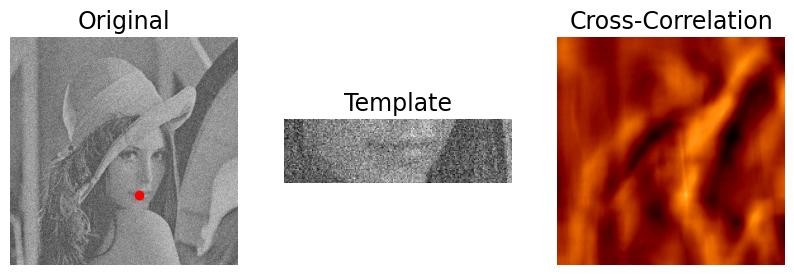

In [7]:
plt.figure(figsize=(10, 6))

plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title('Original', size=17)
plt.plot(x, y, 'ro')
plt.axis('off')

plt.subplot(132)
plt.imshow(template_img, cmap='gray')
plt.title('Template', size=17)
plt.axis('off')

plt.subplot(133)
plt.imshow(correlation, cmap='afmhot')
plt.title('Cross-Correlation', size=17)
plt.axis('off')
plt.show()